AO* ALGORITHM RESULT
Optimal Cost : 6

Optimal Solution Subgraph:
A -> C
C -> JK
JK -> J
JK -> K

Final Solution:
A -> C -> (J AND K)

Total Cost = 6


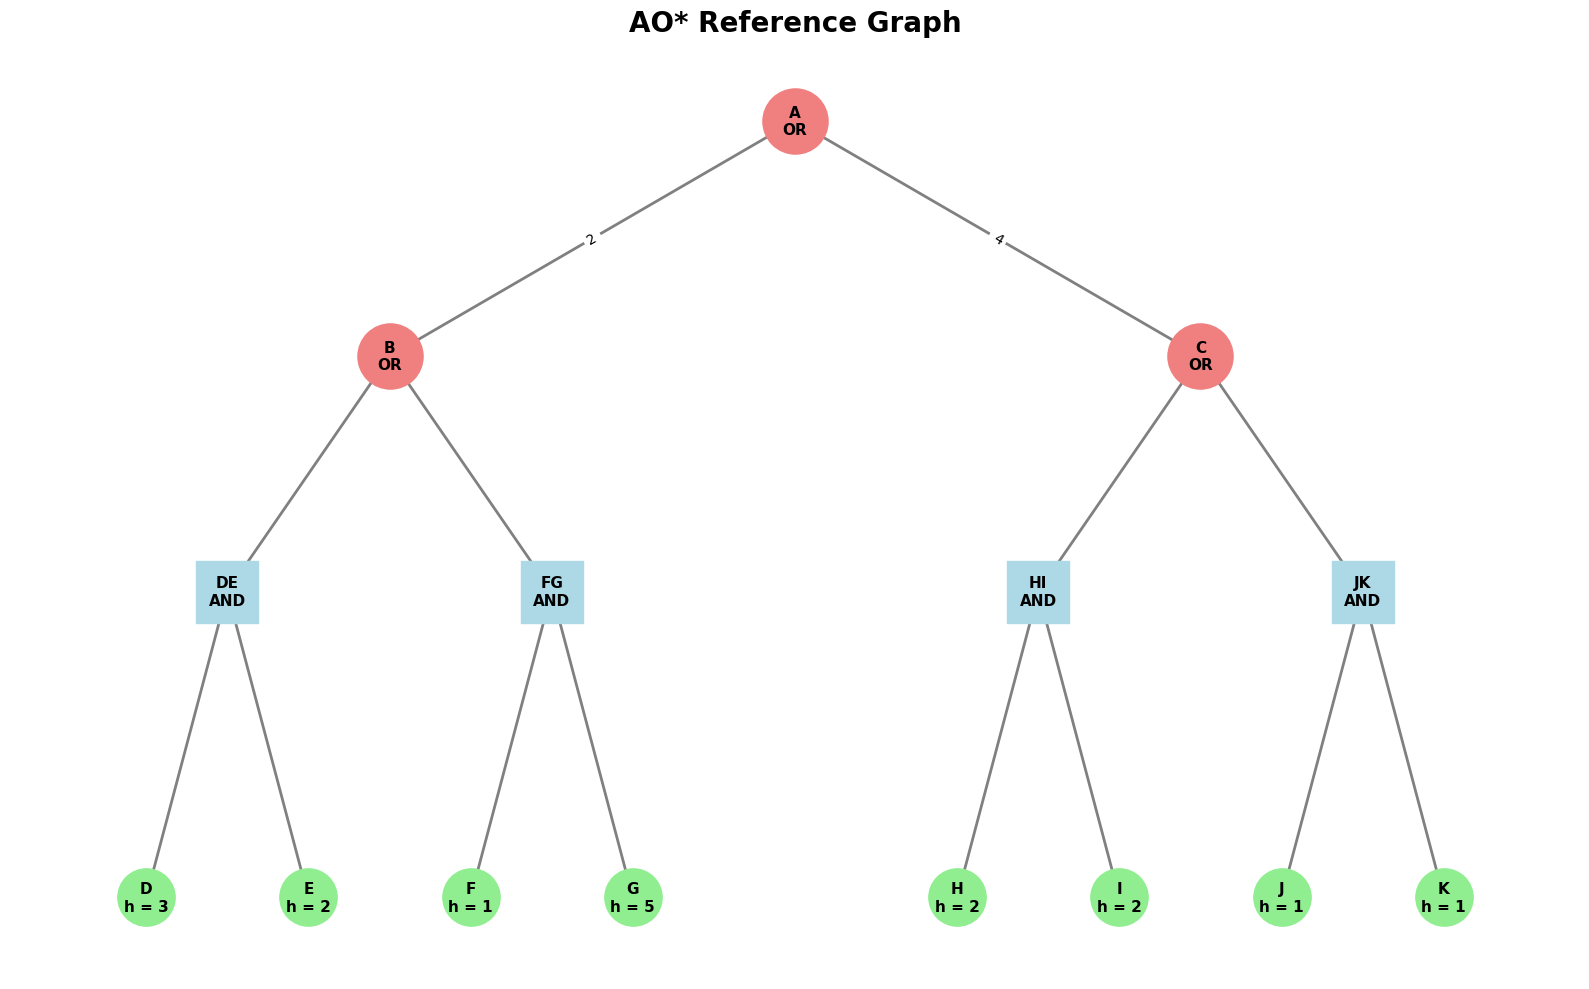

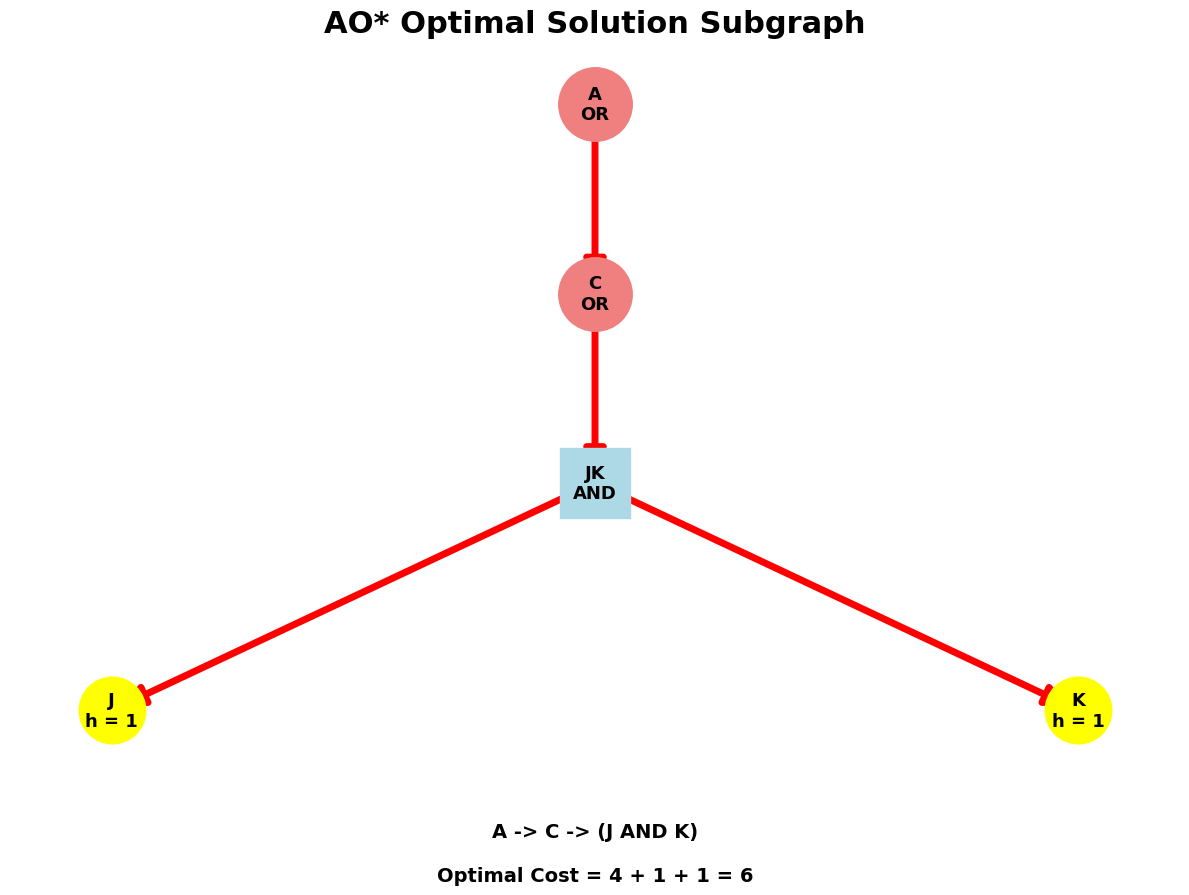

In [1]:
import networkx as nx
import matplotlib.pyplot as plt


graph = {
    "A": {
        "type": "OR",
        "children": [
            ("B", 2),
            ("C", 4)
        ]
    },

    "B": {
        "type": "OR",
        "children": [
            ("DE", 0),
            ("FG", 0)
        ]
    },

    "C": {
        "type": "OR",
        "children": [
            ("HI", 0),
            ("JK", 0)
        ]
    },

    "DE": {
        "type": "AND",
        "children": [
            ("D", 0),
            ("E", 0)
        ]
    },

    "FG": {
        "type": "AND",
        "children": [
            ("F", 0),
            ("G", 0)
        ]
    },

    "HI": {
        "type": "AND",
        "children": [
            ("H", 0),
            ("I", 0)
        ]
    },

    "JK": {
        "type": "AND",
        "children": [
            ("J", 0),
            ("K", 0)
        ]
    },

    "D": {"type": "GOAL", "cost": 3},
    "E": {"type": "GOAL", "cost": 2},
    "F": {"type": "GOAL", "cost": 1},
    "G": {"type": "GOAL", "cost": 5},
    "H": {"type": "GOAL", "cost": 2},
    "I": {"type": "GOAL", "cost": 2},
    "J": {"type": "GOAL", "cost": 1},
    "K": {"type": "GOAL", "cost": 1}
}


def ao_star(node):

    node_type = graph[node]["type"]

    if node_type == "GOAL":
        return graph[node]["cost"], []

    if node_type == "AND":

        total_cost = 0
        solution_edges = []

        for child, edge_cost in graph[node]["children"]:

            child_cost, child_edges = ao_star(child)

            total_cost += edge_cost + child_cost

            solution_edges.append((node, child))
            solution_edges.extend(child_edges)

        return total_cost, solution_edges

    if node_type == "OR":

        alternatives = []

        for child, edge_cost in graph[node]["children"]:

            child_cost, child_edges = ao_star(child)

            total_cost = edge_cost + child_cost

            alternatives.append(
                (total_cost, child, child_edges)
            )

        best_cost, best_child, best_edges = min(
            alternatives,
            key=lambda x: x[0]
        )

        solution_edges = [
            (node, best_child)
        ]

        solution_edges.extend(best_edges)

        return best_cost, solution_edges


optimal_cost, optimal_edges = ao_star("A")

print("=" * 60)
print("AO* ALGORITHM RESULT")
print("=" * 60)

print("Optimal Cost :", optimal_cost)

print("\nOptimal Solution Subgraph:")

for source, target in optimal_edges:
    print(source, "->", target)

print("\nFinal Solution:")
print("A -> C -> (J AND K)")

print("\nTotal Cost = 6")


# ---------------------------------------------------------------
# Create complete graph
# ---------------------------------------------------------------

G = nx.DiGraph()

for node in graph:

    G.add_node(node)

    if graph[node]["type"] != "GOAL":

        for child, cost in graph[node]["children"]:

            G.add_edge(
                node,
                child,
                weight=cost
            )


# ---------------------------------------------------------------
# Reference graph positions
# ---------------------------------------------------------------

reference_pos = {

    "A": (0, 6),

    "B": (-3, 5),
    "C": (3, 5),

    "DE": (-4.2, 4),
    "FG": (-1.8, 4),
    "HI": (1.8, 4),
    "JK": (4.2, 4),

    "D": (-4.8, 2.7),
    "E": (-3.6, 2.7),

    "F": (-2.4, 2.7),
    "G": (-1.2, 2.7),

    "H": (1.2, 2.7),
    "I": (2.4, 2.7),

    "J": (3.6, 2.7),
    "K": (4.8, 2.7)
}


labels = {

    "A": "A\nOR",
    "B": "B\nOR",
    "C": "C\nOR",

    "DE": "DE\nAND",
    "FG": "FG\nAND",
    "HI": "HI\nAND",
    "JK": "JK\nAND",

    "D": "D\nh = 3",
    "E": "E\nh = 2",

    "F": "F\nh = 1",
    "G": "G\nh = 5",

    "H": "H\nh = 2",
    "I": "I\nh = 2",

    "J": "J\nh = 1",
    "K": "K\nh = 1"
}


# ---------------------------------------------------------------
# Draw reference graph
# ---------------------------------------------------------------

plt.figure(figsize=(16, 10))

or_nodes = [
    n for n in G.nodes()
    if graph[n]["type"] == "OR"
]

and_nodes = [
    n for n in G.nodes()
    if graph[n]["type"] == "AND"
]

goal_nodes = [
    n for n in G.nodes()
    if graph[n]["type"] == "GOAL"
]


nx.draw_networkx_edges(
    G,
    reference_pos,
    edge_color="gray",
    width=2,
    arrows=True,
    arrowsize=20
)


nx.draw_networkx_nodes(
    G,
    reference_pos,
    nodelist=or_nodes,
    node_shape="o",
    node_color="lightcoral",
    node_size=2200
)


nx.draw_networkx_nodes(
    G,
    reference_pos,
    nodelist=and_nodes,
    node_shape="s",
    node_color="lightblue",
    node_size=2000
)


nx.draw_networkx_nodes(
    G,
    reference_pos,
    nodelist=goal_nodes,
    node_shape="o",
    node_color="lightgreen",
    node_size=1700
)


nx.draw_networkx_labels(
    G,
    reference_pos,
    labels=labels,
    font_size=11,
    font_weight="bold"
)


edge_labels = nx.get_edge_attributes(
    G,
    "weight"
)

edge_labels = {
    edge: value
    for edge, value in edge_labels.items()
    if value != 0
}


nx.draw_networkx_edge_labels(
    G,
    reference_pos,
    edge_labels=edge_labels
)


plt.title(
    "AO* Reference Graph",
    fontsize=20,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    "AO_star_REFERENCE_GRAPH.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------------
# Draw optimal solution
# ---------------------------------------------------------------

S = nx.DiGraph()

for source, target in optimal_edges:
    S.add_edge(source, target)


solution_pos = {

    "A": (0, 4),
    "C": (0, 3),
    "JK": (0, 2),

    "J": (-1.2, 0.8),
    "K": (1.2, 0.8)
}


plt.figure(figsize=(12, 9))


nx.draw_networkx_edges(
    S,
    solution_pos,
    edge_color="red",
    width=5,
    arrows=True,
    arrowsize=30
)


nx.draw_networkx_nodes(
    S,
    solution_pos,
    nodelist=["A", "C"],
    node_shape="o",
    node_color="lightcoral",
    node_size=2800
)


nx.draw_networkx_nodes(
    S,
    solution_pos,
    nodelist=["JK"],
    node_shape="s",
    node_color="lightblue",
    node_size=2500
)


nx.draw_networkx_nodes(
    S,
    solution_pos,
    nodelist=["J", "K"],
    node_shape="o",
    node_color="yellow",
    node_size=2300
)


solution_labels = {

    "A": "A\nOR",
    "C": "C\nOR",
    "JK": "JK\nAND",
    "J": "J\nh = 1",
    "K": "K\nh = 1"
}


nx.draw_networkx_labels(
    S,
    solution_pos,
    labels=solution_labels,
    font_size=13,
    font_weight="bold"
)


plt.title(
    "AO* Optimal Solution Subgraph",
    fontsize=22,
    fontweight="bold"
)


plt.text(
    0,
    -0.1,
    "A -> C -> (J AND K)\n\n"
    "Optimal Cost = 4 + 1 + 1 = 6",
    ha="center",
    fontsize=14,
    fontweight="bold"
)


plt.axis("off")
plt.tight_layout()


plt.savefig(
    "AO_star_OPTIMAL_SOLUTION.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()